# Stage 1 — session assembly and 10x glomerular segmentation

Working record for segmentation of glomeruluar odor-evoked activity in SACs and MTC dendrites. Everything below runs on **single sessions streamed from the ACC drive**, chosen by `GROUP_ID` in the setup
cell.

The code lives in `tmp/analysis/` and is written against a `group` object with
the same attribute surface as `odyn.Group`, so each entry point can later be
wrapped in `@record_call` and moved into odyn unchanged (section 11).

**Contents**
1. Setup — resolve a session from the database
2. Timing sources and what each one gives you
3. The `acq_start` offset — a clock mismatch, not a delay
4. Trial table, blocks, and the manipulation label
5. Per-odor z-score movies — pooled or split
6. Correlation image
7. Segmentation parameters and how they transfer between sessions
8. Merging per-odor masks
9. Segmentation GUI — tune, merge, curate
10. Results for this session
11. Retrofitting into odyn

## 1. Setup — resolve a session from the database

`resolve_group` returns the motion-corrected paths, odor windows, odor ids
and block labels for one experiment. It reads paths from `mcor_files` where the
database has them and falls back to the directory where it does not — only 15
of 215 experiments were motion-corrected through `Group.run_motion_correction`,
so the fallback is the common case, and `path_source` records which was used.

`LocalGroup` stands in for `odyn.Group`, reading a snapshot of the database
rather than the live one on the share. The **imaging data is read from the
share either way** — only the small database file is local.

Two knobs worth setting deliberately:

- `MANIPULATION` — what happened between the blocks. There is no field for it
  in the database; it lives in the session manifest.
- `SEPARATE_BY_CONDITION` — pool the blocks (default) or keep them apart.
- `APPROVED_ONLY` — restrict to acquisitions approved in `mcor_files`.

In [2]:
# Pick up edits to analysis/ without restarting the kernel. Without this,
# Jupyter keeps the first-imported copy of every module for the life of the
# kernel so a fix to the package appears to have no effect.
%load_ext autoreload
%autoreload 2

import sys, json, shutil, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")          # repo root -> `analysis` package

from analysis.session.devshim import LocalGroup
from analysis.session.resolve import experiments_in_group, resolve_group
from analysis.session.trials import summarize, is_anesthetic
from analysis.session.zscore import make_group_keys
from analysis.session.corrcache import build_group_correlation_maps
from analysis.session.summary import local_correlation
from analysis.seg_10x.watershed import (
    segment_per_group, scale_params, GLOM_10X_DEFAULTS,
)
from analysis.session.merge import merge_masks

# ---- what to run -------------------------------------------------------
# Groups, not experiments. A group is usually one experiment, but a session
# can also be split in two -- same animal, same field of view, one block before
# the manipulation and one after -- and those must be analysed together, since
# the point is a within-glomerulus comparison across them.
#
# The two id spaces overlap, which is a live trap: group 217 is exp 213, while
# exp 217 is a different session entirely that has not been motion corrected.
# Asking by group removes the ambiguity.
GROUP_ID = 217                       # 20260805_m426_e1, Thy1-GCaMP, 16 odors
MANIPULATION = "ketxyl"              # default is "ketamine/xylazine"
# Detection is state-agnostic, per the Stage 1 spec: "Detection once,
# state-agnostic ... Never per state." Separating also splits 160 trials over
# 32 groups, and because the olfactometer randomises with replacement rather
# than counterbalancing, group sizes then run 1-10. A one-trial "trial average"
# is a single trial of noise: on group 217 that produced two unusable maps,
# one of which looked like a different animal.
SEPARATE_BY_CONDITION = False        # pool the two blocks for detection

# Use only acquisitions marked approved in mcor_files. This is where per-trial
# QC belongs -- a PMT-off trial, a mangled registration, a z-jump -- recorded
# in the database so the judgement travels with the data instead of living in
# a hardcoded list here. resolve_group raises rather than silently returning
# nothing if no rows are approved.
APPROVED_ONLY = False

PRE_S, POST_S, SIGMA_PX = 2.0, 3.0, 0.5

# Local scratch: the z-movie accumulators and the database snapshot live here.
#
# Not /tmp (macOS purges it, and it is cleared on reboot), and NOT anywhere
# under the OneDrive folder -- including inside this repo, which is itself in
# OneDrive. The accumulators are gigabytes and are written continuously, so
# OneDrive would try to sync them mid-write: wasted bandwidth at best, a stalled
# sync client or a lock on a file a run is using at worst.
SCRATCH = Path.home() / "odyn_scratch"
SCRATCH.mkdir(parents=True, exist_ok=True)
MAIN     = Path("/Volumes/MossLab/ImagingData")  # imaging data lives here
LIVE_DB  = MAIN / ".odyn" / "odyn.db"            # the real one, never read directly
SNAPSHOT = SCRATCH / "odyn_snapshot.db"          # what this notebook reads

# Read a copy, not the live database.
#
# Every accessor on LocalGroup is `SELECT * FROM <table>` into pandas -- whole
# tables, 23k rows for `acquisitions`. Over SMB that holds a SQLite SHARED lock
# for seconds to minutes, and a writer needs EXCLUSIVE with only DB_TIMEOUT_S
# (30 s) of patience. That is what killed a motion-correction run on 2026-08-12
# after hours of compute. Read-only does not help -- it stops this notebook
# corrupting anything, not making others wait.
#
# `snapshot_to` copies the database first with SQLite's backup API, which is
# transaction-aware (a plain `cp` of a live database can catch it mid-write and
# produce a file that opens fine and is subtly wrong) and yields the lock
# between chunks, so a writer waits milliseconds rather than the whole copy.
# The copy refreshes whenever the live file changes, so it cannot go stale.
# Pass refresh=True to force one.
group = LocalGroup(LIVE_DB, MAIN, snapshot_to=SNAPSHOT)

if group.snapshot:
    snap = group.snapshot
    if snap.get("current"):
        print(f"snapshot: reused, already current · {snap['size_mb']} MB")
    elif snap.get("reused_previous"):
        print(f"snapshot: ! live database too busy to copy within the lock "
              f"budget; using a copy {snap['age_s']:.0f} s old")
    else:
        print(f"snapshot: {snap['method']} · {snap['size_mb']} MB · "
              f"{snap['seconds']:.1f} s · {snap['mb_per_s']} MB/s")
        # Restarts should be 0: VACUUM INTO runs in one read transaction and
        # cannot be invalidated by a write. Anything above 0 means it fell back
        # to the backup API, which a busy writer can make restart repeatedly --
        # 26 restarts and 222 s on 2026-08-12, before this was fixed.
        if snap.get("restarts"):
            print(f"  ! {snap['restarts']} restart(s) — fell back to the "
                  f"backup API; the share is busy")

t0 = time.time()
session = resolve_group(group, group_id=GROUP_ID, manipulation=MANIPULATION,
                        approved_only=APPROVED_ONLY)

members = experiments_in_group(group, GROUP_ID)
if len(members) > 1:
    print(f"group {GROUP_ID} is a split session: exps {members}, "
          f"ordered by start time -- first is pre, second is post")
print(f"resolved in {time.time() - t0:.0f} s")
print(json.dumps(session.summary(), indent=2))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
snapshot: ! live database too busy to copy within the lock budget; using a copy 68936 s old
resolved in 12 s
{
  "exp_id": 213,
  "exp_name": "20260805_m426_e1",
  "group_id": 217,
  "n_acquisitions": 160,
  "frame_rate": 25.068,
  "shape_px": [
    600,
    526
  ],
  "um_per_px_reported": 2.0,
  "timing_source": "acquisition_trigger",
  "path_source": "database",
  "output_dir": "/Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python",
  "odor_on_frame_range": [
    125,
    126
  ],
  "odor_frames_range": [
    100,
    101
  ],
  "n_missing": 0
}


### Database access and locking

The database sits on the SMB share so every machine can reach it, and that is
where "database is locked" comes from. SQLite coordinates writers with
whole-file locks via POSIX advisory locking, which network filesystems
implement inconsistently; WAL mode would let readers run during a write but
needs shared memory and does not work on a network filesystem, so the database
is in rollback-journal mode where a writer excludes everyone.

Two protections here:

- **`LocalGroup` opens read-only** (`mode=ro`), whether pointed at a snapshot
  or the live file. A connection that cannot write cannot take a write lock or
  leave a rollback journal, so this notebook can never contribute to the
  contention that motion correction on other machines is hitting. Its
  `busy_timeout` is 120 s, against odyn's `DB_TIMEOUT_S` of 30.
- **A local snapshot by default.** `DB` above points at a copy; only the
  imaging data and `processed/python` are on the share.

`dblock.inspect` tells contention apart from a stale lock. It reports and never
deletes — **deleting `odyn.db-journal` can destroy the database**, because it
holds the original pages of an interrupted write and is what SQLite uses to
recover. If one is present: confirm nothing is running anywhere, copy both
files, then open the database normally and let SQLite roll it back.

**If this cell reports "not read-only":** Jupyter is holding a stale copy of
the module, not a bug in the code. Restart the kernel. `%autoreload 2` is set
in the setup cell, but it only applies to modules imported *after* it runs --
a kernel that imported them earlier keeps the old ones.

In [4]:
from analysis.session.dblock import inspect as inspect_db

# Reports only; never deletes anything.
state = inspect_db(MAIN / ".odyn" / "odyn.db")
print(f"readable {state['readable']} · writable {state['writable']} · "
      f"journal {state['journal']['present']} · mode {state.get('journal_mode')}")
print(f"-> {state['diagnosis']}\n")

# Assert read-only by asking, not by probing. A probe write fails for reasons
# other than permissions ("table already exists"), which a try/except reads as
# success -- and if the module in memory is stale the probe genuinely writes.
import analysis.session.devshim as _devshim

if not getattr(group, "read_only", False):
    raise RuntimeError(
        "This LocalGroup is NOT read-only, which means Jupyter is holding a "
        "stale copy of the module. Restart the kernel (or use %autoreload 2). "
        f"Module loaded from: {_devshim.__file__}"
    )

print(f"connection read-only : {group.read_only}")
print(f"devshim loaded from  : {_devshim.__file__}")

readable True · writable True · journal False · mode delete
-> Healthy: readable, writable, no journal.

connection read-only : True
devshim loaded from  : /Users/mosse/Library/CloudStorage/OneDrive-OregonHealth&ScienceUniversity/Code/Python/ODyn/tmp/analysis/../analysis/session/devshim.py


## 2. Timing sources

Three routes, in order of preference. `resolve_group` takes the best the
session has and records it in `timing_source`.

| source | what it uses | precision |
|---|---|---|
| `frame_clock` | `sync/*.h5` — `2pFrameSync` + `odorPulse` | exact, per frame |
| `acquisition_trigger` | `*_00001.h5` — `ImagingWindow` + `OdorDelivery` | odor against each acquisition's own trigger; assumes the nominal rate holds within an acquisition |
| `database` | `baseline_s` from the trial table | ~10 ms on both sessions checked |

The frame-clock route was validated on **exp 202** (2026_07_13_m462_e1), which
has a behaviour-DAQ sync file: 224 acquisition blocks of exactly 568 frames
each against a database `frame_count` of 568, a measured 28.390 Hz against a
nominal 28.40, and 224 valve pulses of 4.016 s against a recorded 4.014 s.
Imaging, olfactometer and database agreeing independently.

Sessions before mid-2026 predate `record_behavior.py` and have no frame clock.
Their olfactometer h5 still carries one trigger pulse per acquisition and the
valve, on the same 5 kHz clock — enough to time odor onset without one.

In [5]:
print(f"timing source : {session.timing_source}")
print(f"path source   : {session.path_source}")
print(f"acquisitions  : {len(session.paths)}  (missing {len(session.missing)})")
print(f"odor onset    : frame {min(session.odor_on_frames)}"
      f"-{max(session.odor_on_frames)}")
print(f"odor duration : "
      f"{min(b - a for a, b in zip(session.odor_on_frames, session.odor_off_frames))}"
      f"-{max(b - a for a, b in zip(session.odor_on_frames, session.odor_off_frames))}"
      f" frames at {session.frame_rate:.3f} Hz")
print(f"first path    : ...{str(session.paths[0])[-64:]}")

timing source : acquisition_trigger
path source   : database
acquisitions  : 160  (missing 0)
odor onset    : frame 125-126
odor duration : 100-101 frames at 25.068 Hz
first path    : .../20260805/m426/e1/processed/mcor/20260805_m426_e1_00001_mcor.tif


## 3. The `acq_start` offset — a clock mismatch, not a delay

Two computer clocks are involved, and mixing them costs 35 frames.

| source | clock | fields |
|---|---|---|
| olfactometer CSV | A | `trial_start`, `odor_start` |
| ScanImage TIFF / h5 | B | `acq_start` |

`acq_start` is per-acquisition and faithful — `epoch + frameTimestamps_sec` of
page 0, i.e. the first frame's own timestamp — and agrees with the h5 to
**0.095 ms**. Consecutive intervals from `acq_start` track the frame clock to
within 62 ms, with 259 ms of slow drift over 2.4 h: two free-running clocks,
not a fixed delay.

**odyn already measures the offset.** `h5_to_trial_ms`, defined in
`_match_csv_to_h5` as `(csv_start - h5_start)`, is the entire discrepancy. It
is stored per trial and never applied.

| computation | exp 202 | exp 132 |
|---|---|---|
| `odor_start - acq_start` | 6.2503 s — **mixes clocks** | — |
| `odor_start - trial_start` | 5.0105 s | 5.013 s |
| measured from sync | 5.0077 s | 5.0166 s |
| `clock_offset_s` | 1.241 s | **0.364 s** |

The offset differs per session, so no constant would have worked.
`_calculate_frame_window` in the old `odor_zscore_movies` computed
`(odor_start - acq_start) * frame_rate` and landed 35 frames late — putting
the first 1.24 s of the odor response inside the baseline, which shrinks every
measured response.

`trials.baseline_s` now uses `odor_start - trial_start`, both on clock A.

In [6]:
table = session.table
print(json.dumps(summarize(table), indent=2))
print(f"\nper-trial baseline: {table.baseline_s.median():.4f} s "
      f"(sd {table.baseline_s.std()*1000:.1f} ms)")
print(f"clock-mixed version: {table.odor_minus_acq_start_s.median():.4f} s "
      f"-- {(table.odor_minus_acq_start_s - table.baseline_s).median()*session.frame_rate:.0f} "
      f"frames late")

{
  "n_trials": 160,
  "n_odors": 16,
  "n_blocks": 2,
  "trials_per_block": {
    "0": 80,
    "1": 80
  },
  "manipulation": "ketxyl",
  "block_gap_s": 810.3,
  "odor_duration_s": 4.014,
  "baseline_s": 5.014,
  "clock_offset_s": 1.307,
  "trials_missing_acq": 0
}

per-trial baseline: 5.0136 s (sd 6.7 ms)
clock-mixed version: 6.3171 s -- 33 frames late


## 4. Trial table, blocks, and the manipulation label

A pre/post session is one `loop` experiment, **one acquisition per trial**, run
as two olfactometer programs with the manipulation in the gap between them.
Block comes from `program_id`. There is no injection frame — no imaging happens
during the gap — so it is a block boundary, and the gap length varies widely
(9.0 min here, 34.8 min on exp 202) because block 2 starts when the animal is
ready rather than after a fixed wait.

**What the manipulation was is not in the database.** It is passed in and
recorded per row. `state` is the neutral `pre`/`post`; an earlier version
hardcoded `awake`/`anesthetized`, which is wrong for a saline control — both
blocks are awake — and would have mislabelled every control silently.

In [7]:
print(f"manipulation      : {MANIPULATION!r}   anaesthetic: {is_anesthetic(MANIPULATION)}")
print(f"blocks            : {table.block.value_counts().to_dict()}")
print(f"states            : {sorted(table.state.unique())}")
print(f"odors             : {sorted(table.odor_id.unique())}")
print(f"trials per odor   : "
      f"{table.odor_id.value_counts().min()}-{table.odor_id.value_counts().max()}")
table[["trial_in_block", "block", "state", "manipulation",
       "odor_id", "baseline_s", "odor_duration_s"]].head(3)

manipulation      : 'ketxyl'   anaesthetic: False
blocks            : {0: 80, 1: 80}
states            : ['post', 'pre']
odors             : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(10), np.int64(12), np.int64(17), np.int64(18), np.int64(21), np.int64(22), np.int64(30), np.int64(31), np.int64(32), np.int64(39), np.int64(40)]
trials per odor   : 6-13


,trial_in_block,block,state,manipulation,odor_id,baseline_s,odor_duration_s
0,1,0,pre,ketxyl,2,5.005620,4.017280
1,2,0,pre,ketxyl,0,5.016576,4.014269
2,3,0,pre,ketxyl,32,5.016601,4.015267


## 5. Per-odor z-score movies

Each trial is z-scored against its own pre-odor baseline, then averaged within
group. The spatial Gaussian is applied **before** the z-score so it reduces
noise going into the baseline statistics rather than blurring a result whose
noise is already in the denominator.

`SEPARATE_BY_CONDITION` decides the grouping:

- **Pool (default)** — doubles the trials behind each map. In DAT and TH the
  two blocks agree in sign at 93–99% of responsive pixels, so pooling costs
  under 1% of amplitude.
- **Split** — for Thy1 under an actual anaesthetic, where mitral/tufted
  responses can invert and pooling would cancel exactly the units the
  excited/suppressed analysis is about. Under saline there is nothing to
  preserve, so even Thy1 pools.

This is the expensive step: it streams a `pre + odor + post` window from every
acquisition over SMB at ~14 MB/s.

**Caching.** The result is stored under `processed/python/zscore_cache/` on the
share, keyed by a digest of the inputs and every parameter that changes them.
An identical call returns in seconds rather than re-streaming the session --
which matters because tuning segmentation does not touch these movies at all.

The digest includes each input file's size and modification time, so re-running
motion correction misses rather than silently serving movies built from the old
registration. There is one entry per session: a parameter change overwrites it
rather than accumulating, since a 7-odor session is ~2.7 GB.

`work_dir` stays local -- it is scratch for disk-backed accumulation and is
deleted afterwards.

In [9]:
keys = make_group_keys(
    session.odor_ids, session.states,
    separate_by_condition=SEPARATE_BY_CONDITION,
)
print(f"{len(set(keys))} groups from {len(keys)} acquisitions")

# work_dir is LOCAL scratch for disk-backed accumulation -- deleted afterwards,
# no reason to push it over SMB.
# cache_dir is on the SERVER, inside this session's own processed/python, so the
# result survives a kernel restart and access from different machines.
WORK = SCRATCH / f"nb_work_{GROUP_ID}"

# Sweep every stale work directory, not just this experiment's. The build
# deletes its own accumulators now, but an interrupted run -- or a session on a
# different GROUP_ID -- can still leave a directory behind, and each one is the
# size of the output it was building (2.1 GB for seven odors at 600x1000).
for stale in sorted(SCRATCH.glob("nb_work_*")):
    size_gb = sum(p.stat().st_size for p in stale.rglob("*")) / 1e9
    shutil.rmtree(stale)
    print(f"removed stale work dir {stale.name} ({size_gb:.1f} GB)")

print(f"work  (local, temporary): {WORK}")
print(f"cache (server, persists): {session.cache_dir}")

# Cache the correlation maps, not the z-score movies they come from.
#
# The movies are an intermediate: they exist to be collapsed, once, into one
# local-correlation map per group, and everything after this -- segmentation,
# the GUI, the merge -- reads only those maps. Caching the intermediate cost
# 9.09 GB and ~56 min of writing on exp 213 (32 groups x 284 MB over a share
# managing 2.7 MB/s) to produce 40 MB of maps nothing else needed.
#
# The accumulators are still built the same way, on local disk, and deleted
# afterwards. What disappears is pushing 9 GB over SMB and reading it back.
CORR_CACHE = session.output_dir / "correlation_cache"

t0 = time.time()
corr_by_odor, meta = build_group_correlation_maps(
    session.paths,
    odor_on_frames=session.odor_on_frames,
    odor_off_frames=session.odor_off_frames,
    group_keys=keys,
    frame_rate=session.frame_rate,
    pre_s=PRE_S, post_s=POST_S, spatial_sigma_px=SIGMA_PX,
    work_dir=WORK,
    cache_dir=CORR_CACHE,             # omit to disable caching entirely
    # refresh_cache=True,             # force a rebuild
    # keep_movies=True,               # also return the movies (still uncached)
)
elapsed = time.time() - t0

print(f"\ncache {meta['cache'].upper()} — {elapsed:.1f} s"
      f"{'' if meta['cache'] == 'hit' else f' ({elapsed/60:.1f} min)'}")
print(f"  {len(corr_by_odor)} correlation maps -> {CORR_CACHE}")
if meta["cache"] != "hit":
    print(f"  backend {meta['memory_backend']} ({meta['accumulator_gb']} GB), "
          f"span {meta['n_span']} frames")
    print(f"  trials per group: {meta['trials_per_group']}")

if WORK.exists():
    shutil.rmtree(WORK)

32 groups from 160 acquisitions
work  (local, temporary): /Users/mosse/odyn_scratch/nb_work_217
cache (server, persists): /Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python/zscore_cache

cache HIT — 8.7 s
  32 correlation maps -> /Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python/correlation_cache


**Memory.** One movie per group is held at once, because trials of a given odor
are scattered through the session. `memory_backend="auto"` uses RAM when the
accumulators fit in half of what is free and memory-maps otherwise — so a 64 GB
workstation or cluster node runs in memory and a small laptop still works.

## 6. Correlation image

Local 8-neighbour correlation on the trial-averaged z-score movie, one map per
group. Measured on exp 202 with everything combined identically, so the
comparison is not confounded by the combination rule:

| image | sigma | contrast |
|---|---|---|
| raw acquisitions | none | 0.0929 |
| z-movie, trial-averaged | none | 0.2137 |
| **z-movie, trial-averaged** | **0.5** | **0.3160** |
| z-movie, trial-averaged | 1.0 | 0.2098 |

`contrast = p99.5 - median`, because a spatial Gaussian raises local
correlation *everywhere* by construction — judged on p99.5 alone sigma=1.0
looks best while actually being worst, and at that width adjacent glomeruli
visibly fuse.

In [10]:
# corr_by_odor comes straight from the cell above now -- the movies are
# collapsed inside build_group_correlation_maps and never held here.

def contrast(image):
    median = np.median(image)
    return np.percentile(image, 99.5) - median, median

for key in sorted(corr_by_odor, key=repr):
    c, med = contrast(corr_by_odor[key])
    print(f"  {key!r:>16}: median {med:+.4f}, contrast {c:.4f}")

       (0, 'post'): median +0.1715, contrast 0.1414
        (0, 'pre'): median +0.1746, contrast 0.1249
       (1, 'post'): median +0.1721, contrast 0.1562
        (1, 'pre'): median +0.1787, contrast 0.2069
      (10, 'post'): median +0.1717, contrast 0.1386
       (10, 'pre'): median +0.1790, contrast 0.1421
      (12, 'post'): median +0.2824, contrast 0.2252
       (12, 'pre'): median +0.1770, contrast 0.1542
      (17, 'post'): median +0.1797, contrast 0.2393
       (17, 'pre'): median +0.1809, contrast 0.3256
      (18, 'post'): median +0.1817, contrast 0.2773
       (18, 'pre'): median +0.1806, contrast 0.3460
       (2, 'post'): median +0.1756, contrast 0.2486
        (2, 'pre'): median +0.1898, contrast 0.5406
      (21, 'post'): median +0.1914, contrast 0.5430
       (21, 'pre'): median +0.1817, contrast 0.2457
      (22, 'post'): median +0.1818, contrast 0.4322
       (22, 'pre'): median +0.1880, contrast 0.4900
       (3, 'post'): median +0.1754, contrast 0.2997
        (3, 

## 7. Segmentation parameters

Sizes are in **pixels**. `width_um / width_px` is uncalibrated at 10x, so its
absolute value is wrong there and converting through it would bake that error
in while looking principled.

The miscalibration is a fixed factor, though, so the **ratio** between two
sessions at the same magnification divides it out. `scale_params` uses that to
carry the reference parameters to any other 10x session — verified exp 202
(2.0 µm/px) → exp 132 (1.0 µm/px): predicted 40–110 px against a hand-tuned
optimum of 40–110 px, 34 ROIs against 35. Only within one magnification; a
10x-to-20x ratio does not divide the factor out.

What each part is for, measured on exp 202:

- **adaptive threshold + global floor** — recovers dim glomeruli. The floor
  stops the local rule manufacturing ROIs from noise where there is no
  structure; without it, 126 ROIs became 257.
- **`peak_distance`** — at half the minimum diameter the watershed shattered
  glomeruli into fragments that then failed the size floor: 316 seeds where
  there were perhaps 30 glomeruli.
- **`split_oversized`** — fused bright plateaus get re-seeded rather than
  discarded. Recovered 5,823 px in two regions and lifted coverage of the
  brightest pixels from 28% to 86%.

In [11]:
params = scale_params(GLOM_10X_DEFAULTS, to_um_per_px=session.um_per_px)
print(f"reference (2.0 um/px): {GLOM_10X_DEFAULTS}")
print(f"scaled to {session.um_per_px:.2f} um/px: {params}")

masks, order, records = segment_per_group(corr_by_odor, **params)
for key, record in zip(order, records):
    print(f"  {key!r:>16}: {record['n_rois']:>4} ROIs  "
          f"({record['n_seeds']} seeds -> {record['n_before_size_filter']} regions)")

reference (2.0 um/px): {'mode': 'watershed', 'threshold_pctl': 60.0, 'adaptive_block_px': 101, 'min_diameter_px': 20.0, 'max_diameter_px': 55.0, 'peak_distance_px': 20.0, 'split_oversized': True}
scaled to 2.00 um/px: {'mode': 'watershed', 'threshold_pctl': 60.0, 'adaptive_block_px': 101, 'min_diameter_px': 20.0, 'max_diameter_px': 55.0, 'peak_distance_px': 20.0, 'split_oversized': True}
       (0, 'post'):    7 ROIs  (189 seeds -> 189 regions)
        (0, 'pre'):   23 ROIs  (197 seeds -> 197 regions)
       (1, 'post'):   15 ROIs  (190 seeds -> 190 regions)
        (1, 'pre'):   38 ROIs  (174 seeds -> 174 regions)
      (10, 'post'):   22 ROIs  (198 seeds -> 198 regions)
       (10, 'pre'):   30 ROIs  (196 seeds -> 196 regions)
      (12, 'post'):   58 ROIs  (169 seeds -> 211 regions)
       (12, 'pre'):   34 ROIs  (180 seeds -> 180 regions)
      (17, 'post'):   42 ROIs  (194 seeds -> 194 regions)
       (17, 'pre'):   39 ROIs  (169 seeds -> 169 regions)
      (18, 'post'):   40 ROIs

## 8. Merging per-odor masks

Segmenting each odor separately exploits sparsity: in any one odor's map only a
subset of glomeruli respond, so they are well separated, where a combined image
fuses neighbours. The same glomerulus found under several odors then has to be
recognised as one unit.

**Complete linkage, not connected components.** Thresholding overlap and taking
connected components *is* single linkage, whose classic pathology is chaining —
A–B and B–C merge A with C even when A and C do not overlap, walking across a
row of neighbours. Complete linkage requires every pair in a group to clear
threshold, so a chain cannot form, and two ROIs from the same map never merge.

**One connected region per ROI.** A `consensus_fraction` above 0 votes pixel by
pixel, so the rim — where the odors disagree about the boundary — comes out as a
halo of isolated pixels, and the disjointness pass can then cut what remains
into islands. A size floor on the *total* does not catch this: 700 scattered
pixels pass a 707 px floor as easily as one 700 px disc, and that ROI's trace
averages fluorescence from wherever its specks landed. Measured here, 70 of 132
merged ROIs were non-contiguous, one in 132 pieces. Each merged footprint now
keeps only its largest connected component before the floor is applied, which
makes the floor mean what it says and needs no extra parameter.

In [12]:
print(f"{'min_overlap':>12}{'ROIs':>7}{'>1 odor':>9}{'>=3':>6}")
for min_overlap in (0.2, 0.3, 0.5, 0.7):
    m = merge_masks(masks, min_overlap=min_overlap, metric="iou",
                    linkage="complete",
                    min_area_px=np.pi * (params["min_diameter_px"] / 2) ** 2)
    d = m.detections_per_roi()
    print(f"{min_overlap:>12}{m.n_rois:>7}{int((d > 1).sum()):>9}{int((d >= 3).sum()):>6}")

merged = merge_masks(masks, min_overlap=0.5, metric="iou", linkage="complete",
                     min_area_px=np.pi * (params["min_diameter_px"] / 2) ** 2)
areas = np.bincount(merged.labels.ravel())[1:]
diameters = 2 * np.sqrt(areas / np.pi)
print(f"\nmerged: {merged.n_rois} ROIs, diameter "
      f"{diameters.min():.0f}-{diameters.max():.0f} px "
      f"(median {np.median(diameters):.0f})")

 min_overlap   ROIs  >1 odor   >=3
         0.2    128      112    87
         0.3    146      121    93
         0.5    167       86    54
         0.7    178       47    24

merged: 167 ROIs, diameter 20-56 px (median 26)


## 9. Segmentation GUI — tune, merge, curate

Bokeh, matching `Group.pick_mcor_parameters` — same `output_notebook()` +
`bpl.show(modify_doc)` pattern and the same VSCode workaround, so neither
interactive tool needs a matplotlib backend.

Three phases, sequential:

- **TUNE** — six sliders re-run per-odor segmentation live, shared or
  overridden per odor.
- **MERGE** — segmentation freezes; `min_overlap`, `min_detections` and
  `consensus_fraction` are live with the merged mask updating.
- **CURATE** — everything freezes; edits apply to the **merged** mask.

Curation comes after merging deliberately: curating each odor separately would
repeat the same judgements up to sixteen times and leave the merge reconciling
decisions a human already made.

**Exclude polygon:** select the tool, tap the image to place vertices, then press **Close polygon** (or **Cancel polygon**). Closing used to be a double-tap, but Bokeh emits two `Tap` events before a `DoubleTap`, so the closing double-click appended two spurious vertices and the callback order was not guaranteed.

**Manual seeds are judged by looser bounds than the automatic pass** (see
`manual_bounds`): diameter range halved at the bottom and 1.5× at the top,
local threshold dropped 25 percentiles, and no minimum seed separation at all.
The automatic parameters are tuned to be *selective* — they decide which of
thousands of candidate maxima become ROIs. A click is not a candidate: someone
looked and asserted a glomerulus is there, so there is no false-positive rate to
control and the same thresholds only overrule the person using the tool. The one
constraint that does not relax is disjointness, since two ROIs sharing pixels
would make two traces from one piece of tissue; a click with no free space left
is rejected and the GUI says so.

Added ROIs are **watershed seeds**, not stamped disks, so a hand-placed ROI
grows to fit the image the way an automatic one does and its trace means the
same thing. The **ROI opacity** slider fades the overlay; `border_px` excludes
the frame edge, where `border_nan="copy"` duplicates pixel content that then
correlates perfectly with its neighbours.

In [10]:
RUN_GUI = True        # set True and re-run this cell

if RUN_GUI:
    from analysis.seg_10x.gui import launch
    gui = launch(corr_by_odor,
                 save_path=SCRATCH / f"masks_group{GROUP_ID}.npz",
                 params=params)

Loading BokehJS ...

## 10. Results for this session

Re-run this cell after curating in the GUI and it picks up the curated
mask — it checks for a `gui` in the curate phase rather than reading the
automatic `merged` from section 8, which would silently ignore every
manual edit.


214 ROIs — loaded from group217_20260805_m426_e1_masks_processed_20260813.mat (mat, mask_hash f426747cf02b4983)
saved group217_20260805_m426_e1_masks_processed_20260813.mat
saved group217_20260805_m426_e1_masks_processed_20260813.png

QC stills -> /Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python/correlation_maps
  shared display scale [0.097, 0.55]
         (0, 'post'): contrast 0.1414
          (0, 'pre'): contrast 0.1249
         (1, 'post'): contrast 0.1562
          (1, 'pre'): contrast 0.2069
        (10, 'post'): contrast 0.1386
         (10, 'pre'): contrast 0.1421
        (12, 'post'): contrast 0.2252
         (12, 'pre'): contrast 0.1542
        (17, 'post'): contrast 0.2393
         (17, 'pre'): contrast 0.3256
        (18, 'post'): contrast 0.2773
         (18, 'pre'): contrast 0.3460
         (2, 'post'): contrast 0.2486
          (2, 'pre'): contrast 0.5406
        (21, 'post'): contrast 0.5430
         (21, 'pre'): contrast 0.2457
        (22, 'post'): contr

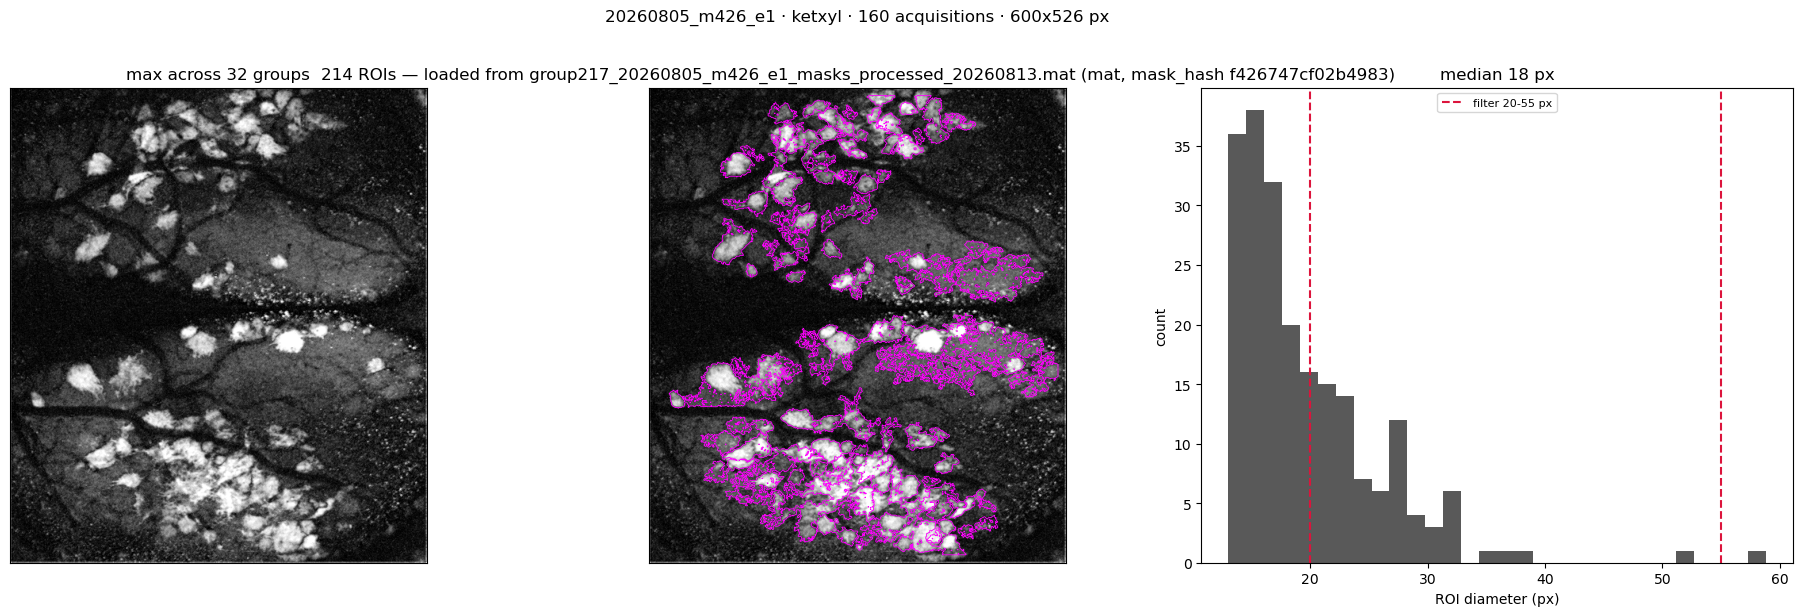

In [13]:
# Prefer the GUI's curated mask when one exists, so re-running this cell after
# curating shows the curated result. Reading `merged` alone would always show
# the automatic masks from section 8, silently ignoring every manual edit.
# Precedence: the live GUI, then the most recent saved mask, then a fresh
# automatic merge.
#
# The saved-mask step is what makes a fresh kernel safe. Curation is the
# expensive human step and every finished run already writes it to the server,
# but nothing read it back -- so restarting the kernel silently fell through to
# the automatic merge, and an hour of extraction could run against ROIs nobody
# approved. Nothing in the output would have said so.
RECOMPUTE_MASK = False        # True to ignore saved masks and re-merge

from analysis.session.masks import load_latest_mask

saved = None if RECOMPUTE_MASK else load_latest_mask(session.output_dir)

if "gui" in dir() and gui.state.phase == "curate":
    labels = gui.state.curated_mask()
    detections = gui.state.merged().detections_per_roi()
    provenance = gui.state.merged_provenance()
    edits = gui.state.curation
    source = (f"curated — {len(edits.deleted)} deleted, "
              f"{len(edits.live_seeds())} added, "
              f"{len(edits.exclude_polygons)} polygon(s)")
elif saved is not None:
    labels = saved["labels"]
    detections = None
    provenance = None
    source = (f"loaded from {saved['path'].name} "
              f"({saved['source']}, mask_hash {saved['mask_hash']})")
    if saved["n_available"] > 1:
        source += f" — {saved['n_available']} saved masks present, took newest"
else:
    labels = merged.labels
    detections = merged.detections_per_roi()
    provenance = None
    source = "automatic (no curation yet)"

n_rois = int(labels.max())
print(f"{n_rois} ROIs — {source}")

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
reference = np.max(np.stack([corr_by_odor[k] for k in order]), axis=0)
v0, v1 = np.percentile(reference, (1, 99.5))

axes[0].imshow(reference, cmap="gray", vmin=v0, vmax=v1)
axes[0].set_title(f"max across {len(order)} groups")
axes[1].imshow(reference, cmap="gray", vmin=v0, vmax=v1)
axes[1].contour(labels > 0, levels=[0.5], colors="magenta", linewidths=0.6)
axes[1].set_title(f"{n_rois} ROIs — {source}")
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])

areas = np.bincount(labels.ravel())[1:]
areas = areas[areas > 0]
diameters = 2 * np.sqrt(areas / np.pi)
axes[2].hist(diameters, bins=30, color="0.35")
axes[2].axvline(params["min_diameter_px"], color="crimson", ls="--")
axes[2].axvline(params["max_diameter_px"], color="crimson", ls="--",
                label=f"filter {params['min_diameter_px']:.0f}-"
                      f"{params['max_diameter_px']:.0f} px")
axes[2].set_xlabel("ROI diameter (px)"); axes[2].set_ylabel("count")
axes[2].set_title(f"median {np.median(diameters):.0f} px"); axes[2].legend(fontsize=8)

fig.suptitle(f"{session.exp_name} · {MANIPULATION} · {len(session.paths)} acquisitions "
             f"· {session.shape[0]}x{session.shape[1]} px", y=1.02)
plt.tight_layout()

# Save the masks the moment they are final, rather than waiting on extraction
# -- which may not run today. Two files, same stem and date as the round:
#
#   ..._masks_processed_<date>.mat   MATLAB reads it as (rows, cols), with no
#                                    permute; h5read on the .h5 transposes.
#   ..._masks_processed_<date>.png   the ROIs over the mean correlation map at
#                                    25% opacity, as the GUI drew them.
#
# `finalize_session` writes the same two names later, so re-running with
# extraction on refreshes them rather than leaving a second copy behind.
from analysis.session.finalize import mask_hash
from analysis.session.masks import (
    background_image, save_mask_overlay, save_masks_mat,
)
from analysis.session.store import session_filename

def _named(kind, suffix):
    return session.output_dir / session_filename(
        group_id=session.group_id, exp_name=session.exp_name,
        kind=kind, suffix=suffix,
    )

mat = save_masks_mat(
    _named("masks", ".mat"), labels,
    per_group_masks=dict(zip(order, masks)),
    exp_name=session.exp_name, group_id=session.group_id,
    mask_hash=mask_hash(labels),
)
png = save_mask_overlay(_named("masks", ".png"), background_image(corr_by_odor), labels)
print(f"saved {mat.name}")
print(f"saved {png.name}")

# Quality-control stills, one per group, into processed/python/correlation_maps/
from analysis.session.qc import save_correlation_stills

qc = save_correlation_stills(
    corr_by_odor, session.output_dir,
    context={"exp_name": session.exp_name, "manipulation": MANIPULATION,
             "separate_by_condition": SEPARATE_BY_CONDITION,
             "timing_source": session.timing_source},
)
print(f"\nQC stills -> {session.output_dir / 'correlation_maps'}")
print(f"  shared display scale {[round(v, 3) for v in qc['scale']]}")
for key, stats in qc["groups"].items():
    print(f"    {key:>16}: contrast {stats['contrast']:.4f}")

## 11. Trace extraction

The actual output of Stage 1: one mask applied unchanged to every acquisition.

Detection happened once on the pooled data, so the same pixels are read in both
blocks — which is what makes a within-unit pre/post comparison mean anything.
Re-detecting per block would give two ROI sets needing to be matched, and any
matching error would land squarely on the effect being measured.

**Extraction is tied to segmentation**, not a separate stage. Given a mask it
takes no decisions of its own — there is no parameter to weigh, nothing to
judge. Leaving it separate invites the failure it cannot detect: a mask
re-curated afterwards, and traces on disk describing ROIs nobody is looking at.
Both files would load; nothing would say so. `finalize_session` writes them
together and stamps the mask's content hash into the file, and `verify` reports
a mismatch.

**Output is one self-describing HDF5 per round:**

```
group132_20260317_m316_e1_processed_20260812.h5
^        ^                  ^          ^
group    experiment         stage      processing date
```

Two side-products sit beside it, sharing the stem and date:
`..._masks_processed_<date>.mat` and `..._masks_processed_<date>.png`. The
`.mat` is the mask for MATLAB without the transpose `h5read` imposes; the PNG
is the ROIs over the image at 25% opacity, the way the GUI drew them. Neither
is a source of truth — both carry the same `mask_hash` as the round.

HDF5 rather than `.npz` because **MATLAB cannot read `.npz`**, and this lab
analyses these sessions in MATLAB — every experiment has a `processed/matlab`
folder. `h5disp` lists the whole layout with a plain-language description on
every dataset, and the file carries a `/README`.

The date makes rounds additive: re-curate and re-extract, and the previous
round is still there to compare against.

Contents: `/masks/labels`, `/masks/<odor>`, `/traces/roi`, `/traces/neuropil`,
`/traces/time_s`, `/rois/*` (one row per ROI), `/trials/*` (one row per trial).
Raw fluorescence only — dF/F, baseline-z and neuropil correction are later
decisions, deliberately not baked in here.

This streams the session again — about 60 min for exp 132 — so it is off by
default.

**Response QC runs off the written file**, in seconds, and can be re-run later
without re-streaming. It reports sparsity in both directions — *population*
(what fraction of glomeruli an odor drives) and *lifetime* (how selectively a
glomerulus responds across odors) — which is what says whether this session
looks like odor coding at all. The correlation-map QC in section 10 cannot: a
clean-looking mask can sit over noise.

The two z thresholds are **not constants**. They are read off this session's own
null — the same measurement repeated on windows before the odor, collapsed by
odor exactly as the real one is — at a fixed false-positive rate per tail, and
validated on sham offsets they were not fitted to. That makes the *error rate*
the quantity held constant between sessions, rather than a z value whose meaning
depends on trial count, noise and bleaching. The two tails calibrate
independently, so the asymmetry between excitation and suppression comes out of
the data instead of being assumed. Pass `thresholds="fixed"` when several
sessions must instead share one threshold.

In [14]:
RUN_EXTRACTION = True        # ~60 min for a 180-acquisition session

from analysis.session.finalize import finalize_session, verify

# What is already on disk for this session.
existing = verify(session.output_dir)
print(f"existing rounds: {existing.get('rounds', [])}")
print(f"  status: {existing['status']}")

if RUN_EXTRACTION:
    # The curated mask if the GUI has one, otherwise the automatic merge.
    # `labels` and `source` come from the mask cell above, so extraction can
    # never disagree with the mask that was just displayed and approved.
    mask_for_traces = labels
    mask_source = source
    per_group = {repr(k): m for k, m in zip(order, masks)}
    curation_record = (
        gui.state.summary()
        if "gui" in dir() and gui.state.phase == "curate" else None
    )

    print(f"\nextracting with the {mask_source} mask: "
          f"{int(mask_for_traces.max())} ROIs")

    t0 = time.time()
    result = finalize_session(
        session, mask_for_traces,
        per_group_masks=per_group,
        segmentation_params=params,
        merge_params={"min_overlap": 0.5, "linkage": "complete"},
        curation=curation_record,
        images=corr_by_odor,
        pre_s=PRE_S, post_s=POST_S, neuropil=True,
        # Build locally, then copy. Each trial lands in a local memmap as it
        # completes, so a dropped mount costs the trials still outstanding
        # rather than the whole hour -- re-run this cell and it resumes. The
        # HDF5 is written to scratch and copied, so an interrupted write leaves
        # no file rather than a truncated one that still opens.
        scratch_dir=SCRATCH,
    )
    print(f"finished in {(time.time() - t0)/60:.1f} min")
    print(f"  {result['path']}")
    print(f"  mask_hash {result['mask_hash']}  ·  {result['n_rois']} ROIs")
    print(f"  {Path(result['mask_mat']).name}")
    print(f"  {Path(result['mask_png']).name}  "
          f"(ROIs at {result['overlay_alpha']:.0%} opacity)")
    print(json.dumps(result["summary"], indent=2))

    check = verify(session.output_dir)
    print(f"\nverify: {check['status']}")

    # Response QC. Runs off the file just written, so it costs seconds and can
    # be re-run later without re-streaming. Population sparsity (what fraction
    # of glomeruli an odor drives) and lifetime sparsity (how selectively a
    # glomerulus responds across odors) are the two numbers that say whether
    # this session looks like odor coding at all -- the correlation-map QC in
    # section 10 cannot, since a clean-looking mask can sit over noise.
    from analysis.session.response_qc import response_qc

    qc_response = response_qc(result["path"])
    pooled = qc_response["blocks"]["pooled"]

    print(f"\nresponse QC -> {Path(qc_response['figure']).name}")
    print(f"  lifetime sparseness   median {pooled['lifetime_sparseness']['median']:.2f} "
          f"(0 = responds to everything, 1 = one odor only)")
    print(f"  population sparseness median {pooled['population_sparseness']['median']:.2f}")
    resp = pooled["responsive"]
    print(f"  responsive to any odor: {resp['rois_responsive_to_any']}"
          f"/{resp['n_rois']}  ·  excited (z>={resp['z_excited']:g}) {resp['excited']}"
          f", suppressed (z<={resp['z_suppressed']:g}) {resp['suppressed']}")

    # The thresholds are not constants: they are read off this session's own
    # null at a fixed false-positive rate. The null is the same measurement
    # made on windows before the odor, where nothing happened, collapsed by
    # odor exactly as the real one is. That makes the *error rate* the thing
    # held constant between sessions, rather than a z value whose meaning
    # depends on trial count, noise, and bleaching.
    sham = qc_response["sham"]
    if sham["available"]:
        print(f"  thresholds ({qc_response['thresholds']['source']}) from "
              f"{sham['n_null_samples']:,} null samples at "
              f"{sham['target_fpr']:.0%}/tail")
        print(f"    held-out false positives: "
              f"excited {sham['achieved_fpr']['excited']:.1%}, "
              f"suppressed {sham['achieved_fpr']['suppressed']:.1%}")
    for flag in qc_response["flags"]:
        print(f"  ! {flag}")

    # Sanity: a response should be visible against the pre-odor baseline.
    traces = result["traces"]
    base = traces.roi[:, :, :traces.n_pre].mean(axis=2)
    resp = traces.roi[:, :, traces.n_pre:traces.n_pre + traces.n_odor].mean(axis=2)
    dff = (resp - base) / np.maximum(np.abs(base), 1e-6)
    print(f"\ndF/F over the odor window: median {np.nanmedian(dff):+.4f}, "
          f"p95 {np.nanpercentile(dff, 95):+.4f}")
    print(f"  ROIs with mean dF/F > 0.05: "
          f"{int((np.nanmean(dff, axis=1) > 0.05).sum())} of {traces.n_rois}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    axes[0].plot(traces.time_s, np.nanmean(traces.roi, axis=(0, 1)), lw=2)
    axes[0].axvspan(0, traces.n_odor / traces.frame_rate, color="0.85", zorder=0)
    axes[0].set_xlabel("time from odor onset (s)"); axes[0].set_ylabel("raw F")
    axes[0].set_title("population mean")

    axes[1].hist(np.nanmean(dff, axis=1), bins=40, color="0.35")
    axes[1].set_xlabel("mean dF/F"); axes[1].set_ylabel("ROIs")
    axes[1].set_title("response distribution")
    plt.tight_layout()

existing rounds: []
  status: no rounds found

extracting with the loaded from group217_20260805_m426_e1_masks_processed_20260813.mat (mat, mask_hash f426747cf02b4983) mask: 214 ROIs
resuming extraction: 43/160 trials already done


extracting traces:   0%|          | 0/117 [00:00<?, ?acq/s]

finished in 18.2 min
  /Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python/group217_20260805_m426_e1_processed_20260813.h5
  mask_hash f426747cf02b4983  ·  214 ROIs
  group217_20260805_m426_e1_masks_processed_20260813.mat
  group217_20260805_m426_e1_masks_processed_20260813.png  (ROIs at 25% opacity)
{
  "n_rois": 214,
  "n_trials": 160,
  "n_frames": 502,
  "frame_rate": 25.068,
  "window_s": [
    -5.026,
    14.959
  ],
  "n_pre": 126,
  "n_odor": 100,
  "n_post": 276,
  "full_acquisition": true,
  "roi_area_px": [
    133,
    2716
  ],
  "has_neuropil": true,
  "n_skipped": 0
}

verify: ok

response QC -> group217_20260805_m426_e1_processed_20260813_responseqc.png
  lifetime sparseness   median 0.98 (0 = responds to everything, 1 = one odor only)
  population sparseness median 0.60
  responsive to any odor: 214/214  ·  excited (z>=1.5) 214, suppressed (z<=-0.5) 0
  ! Population sparsity is very low: one odor drove 100% of ROIs. In the bulb that usually means motion, a z

## 12. Retrofitting into odyn

Every entry point already takes `group` first with keyword-only arguments,
which is what `@record_call` requires. Moving into odyn is adding the
decorator:

```python
@record_call
def build_session_masks(group, *, exp_id=132, manipulation="ketamine/xylazine",
                        separate_by_condition=False, min_overlap=0.5):
    ...
    group.set_output({"n_rois": int(merged.n_rois)})
    group.add_output_file(mask_path)
```

Four constraints from `utils.record_call` that the code already respects:

1. **Keyword-only with defaults.** The wrapper is `wrapper(self, **kwargs)` and
   cannot take a second positional argument.
2. **Every parameter JSON-serialisable** — they pass through `json.dumps`
   twice. No `Path`, arrays, or DataFrames as parameters, hence pixel ints and
   floats throughout.
3. **`set_output` is JSON too.** Summary scalars only; cast numpy scalars with
   `float()`/`int()` first.
4. **`add_output_file` needs a live call frame**, so masks are written here and
   registered at retrofit.

Two things to settle at that point:

**`get_git_hash()` is recorded per call**, so the analysis code must be tracked
by git for a logged run to be reproducible. Under `tmp/` it is gitignored, and
every recorded call would carry a commit that does not contain the code that
produced it.

**`mcor_files` covers 15 of 215 experiments.** The rest were corrected outside
odyn and have no per-acquisition provenance, no `source`, and no `approved` —
so `approved_only=True` returns nothing for almost every session. Worth
deciding whether older sessions get registered retroactively before the
analyses lean on that table.